In [2]:
import numpy as np
# import awkward as ak
# import dask
import json
# from coffea import processor
# from coffea.analysis_tools import Weights, PackedSelection

import pandas as pd
import pyarrow.parquet as pq
from tqdm import tqdm
import os
import xgboost as xgb
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.CMS])

In [3]:
with open('samples.json', 'r') as file:
    pmap = json.load(file)

In [30]:
'''processing functions'''
def minjetkin(df):
    # fatjets = df['ak8FatJetmsoftdrop', 'ak8FatJetPt', 'ak8FatJetEta']
    # print(df['ak8FatJetmsoftdrop'].shape)
    fatjet_msd = df['ak8FatJetmsoftdrop'].values[:,0]
    fatjet_pt = df['ak8FatJetPt'].values[:,0]
    fatjet_eta = df['ak8FatJetEta'].values[:,0]
        # fatjets['msdcorr'] = fatjets.msoftdrop
        # fatjets['qcdrho'] = 2 * np.log(fatjets.msdcorr / fatjets.pt)
    candidatejet = df[
            (fatjet_pt > 200)
            & (abs(fatjet_eta) < 2.5)
            # & fatjets.isTight 
        ]
    # candidatejet = candidatejet[:, :2]
    # candidatejet = ak.firsts(candidatejet[ak.argmax(candidatejet.particleNet_XbbVsQCD, axis=1, keepdims=True)])

    # bvl = candidatejet.particleNet_XbbVsQCD
    minjetkin=np.array([
            (candidatejet['ak8FatJetPt'] >= 450)
            & (candidatejet['ak8FatJetPt']< 1200)
            & (candidatejet['ak8FatJetmsoftdrop'] >= 40.)
            & (candidatejet['ak8FatJetmsoftdrop'] < 201.)
            & (abs(candidatejet['ak8FatJetEta']) < 2.5)
       ])
    minjetkin=np.sum(minjetkin, axis=2).astype('bool').transpose()
    # print(minjetkin.shape)
    # print(minjetkin)
    
    return df[minjetkin]

def get_paths(data_path, proc = 'QCD'):
    #returns list of paths to parquet files
    return [os.path.join(data_path, p, 'parquet') for p in pmap[proc]]

def process_single(df, 
                   cuts=False,
                   save_fields = ['weight','ak8FatJetMass'],
                   signal = False,
               ):    
    if cuts: 
        dfc = minjetkin(df.copy(deep=True))
        #add more cuts here
    else:
        dfc = df.copy(deep=True)
                           
    X = dfc[save_fields] 
    X['weight_noxsec'] = abs(X['weight_noxsec'])
    X['weight'] = abs(X['weight'])

    if signal:
        X['isSignal']  = np.ones(X['weight'].shape[0])
        X['category'] = [signal]*X['weight'].shape[0]
    else: 
        X['isSignal'] = np.zeros(X['weight'].shape[0])
        X['category'] = ['QCD']*X['weight'].shape[0]
    del dfc
    return X
    
def df2Dmatrix(X):
    #convert final df to dmatrix for xgb
    dmatrix = xgb.DMatrix(X, label= X['isSignal'], missing = -9999, weight = X['weight_noxsec'])
    return dmatrix

def fill_hist(process, field, cut=False, full=True):
    
    data_dir = './2023' #folder containing all samples
    #collect all field data for the process
    dirs = get_paths(data_dir, process)
    # print(dirs)
    var = None

    for d in tqdm(dirs, desc="Processing "+str(proc)+' '+str(field)):
        # print(d)
        for i, file in enumerate(os.listdir(d)):
            path = os.path.join(d,file)
            # print(path)
            # print(path)
            if var is None:
                var = get_proc_field(path, field, cut=cut)
                # print(var.shape, var)
            else:
                var = np.append(var, get_proc_field(path, field, cut=cut).values, axis=0)
                # print(var.shape, type(var))
            # if not full:
            #     print('stored var from only 1 parquet')
            #     break
    return var

def accumulator(proc, isSignal=False, shallow=True): #perform data accumulation for a particular process
    data_dir = './2023'
    dirs = get_paths(data_dir, proc)
    # print(dirs)
    data = None
    for d in tqdm(dirs, desc="Processing "+str(proc)): #runs through subsets of a process
        # print(d)
        for i, file in enumerate(os.listdir(d)): #runs through files in subset
            if (i > 0) & shallow: #use only 1 parquet file from each subset if shallow
                # print(file)
                break
            # elif shallow:
            #     break
            # print('parquet name: ', file)
            file_path = os.path.join(d,file)
            df = pd.read_parquet(file_path)
            multiindex_columns = df.columns
            # print(multiindex_columns)
            col_string = 'ak8Fat'
            # # save_cols = [col for col in multiindex_columns if isinstance(col, int) and col_string in col[0]]+['weight']
            save_cols = [col for col in multiindex_columns if ( (col_string in col[0]) #save all ak8fatjet columns and weights
                                                            and ('ass' not in col[0]) 
                                                            and ('soft' not in col[0])
                                                            and ('QCD' not in col[0])
                                                            and ('Xbb' not in col[0])
                                                            and ('raw' not in col[0])
                                                              )] 
            save_cols = save_cols + [('weight', 0)] + [('weight_noxsec', 0)]
            # if i == 0:
                 # print('save_cols: ', save_cols)
            
            thisdf = process_single(df, cuts=True,
                               save_fields = save_cols,
                               signal = isSignal,
                                  ) #apply cuts save select columns, add isSignal column
            if data is None:
                data = thisdf
            else:
                data = pd.concat([data, thisdf], axis = 0, ignore_index=True)
            del thisdf
    return data



In [31]:
''' Accumulate data, prepare it, save to mega DF '''
import warnings
# warnings.filterwarnings('ignore', category=pd.core.common.SettingWithCopyWarning) 
warnings.filterwarnings('ignore') 

def get_paths(data_path, proc = 'QCD'):
    #returns list of paths to parquet files
    return [os.path.join(data_path, p, 'parquet') for p in pmap[proc]]

# shallow = True #take only one parquet from each process/proc subset

samples = ['VBF', 'VH', 'ggF', 'QCD'] #processes to aquire
isSignal = ['VBF', 'VH', 'ggF', False]

X = None

for j, s in enumerate(samples):
    # print(s)
    proc_data = accumulator(s, isSignal=isSignal[j], shallow=True)
    # print(proc_data.columns)
    if X is None:
        X = proc_data
        # print(X.columns)
    else:
        X = pd.concat([X, proc_data], axis = 0, ignore_index=True)
    print(X['isSignal'].shape)
    del proc_data



Processing VBF: 100%|█████████████████████████████| 1/1 [00:00<00:00, 18.93it/s]


(1170,)


Processing VH: 100%|████████████████████████████| 10/10 [00:00<00:00, 28.32it/s]


(26254,)


Processing ggF: 100%|█████████████████████████████| 1/1 [00:00<00:00, 45.38it/s]


(26657,)


Processing QCD: 100%|█████████████████████████████| 9/9 [00:03<00:00,  2.82it/s]

(897276,)


In [32]:
#manual omition of negative weights
print(X.columns)

# print(len(X['weight_noxsec']))

# print(np.sum((X['weight_noxsec']<0).astype(int)))

# w_min = 1E-9
# mask = X['weight_noxsec']>0
# # print(mask)

# X = X.loc[mask[0]]

X['weight_noxsec'] = abs(X['weight_noxsec'])
# print(np.sum((X['weight_noxsec']>0).astype(int)))
print(len(X['weight_noxsec']))


from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=True)

MultiIndex([(         'ak8FatJetEta',  0),
            (         'ak8FatJetEta',  1),
            (         'ak8FatJetPhi',  0),
            (         'ak8FatJetPhi',  1),
            (          'ak8FatJetPt',  0),
            (          'ak8FatJetPt',  1),
            (    'ak8FatJetPNetTXjj',  0),
            (    'ak8FatJetPNetTXjj',  1),
            (    'ak8FatJetPNetTXgg',  0),
            (    'ak8FatJetPNetTXgg',  1),
            (    'ak8FatJetPNetTXcc',  0),
            (    'ak8FatJetPNetTXcc',  1),
            (    'ak8FatJetPNetTXqq',  0),
            (    'ak8FatJetPNetTXqq',  1),
            ('ak8FatJetTau2OverTau1',  0),
            ('ak8FatJetTau2OverTau1',  1),
            ('ak8FatJetTau3OverTau2',  0),
            ('ak8FatJetTau3OverTau2',  1),
            (    'ak8FatJetParTPXcc',  0),
            (    'ak8FatJetParTPXcc',  1),
            (    'ak8FatJetParTPXcs',  0),
            (    'ak8FatJetParTPXcs',  1),
            (    'ak8FatJetParTPXgg',  0),
           

                   0
0       4.184260e+00
1       4.184260e+00
2       4.184260e+00
3       4.184260e+00
4       4.184260e+00
...              ...
897251  1.591540e+08
897252  1.591540e+08
897253  1.591540e+08
897254  1.591540e+08
897255  1.591540e+08

[896951 rows x 1 columns]
0.0068384800106287


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:('category', ''): object

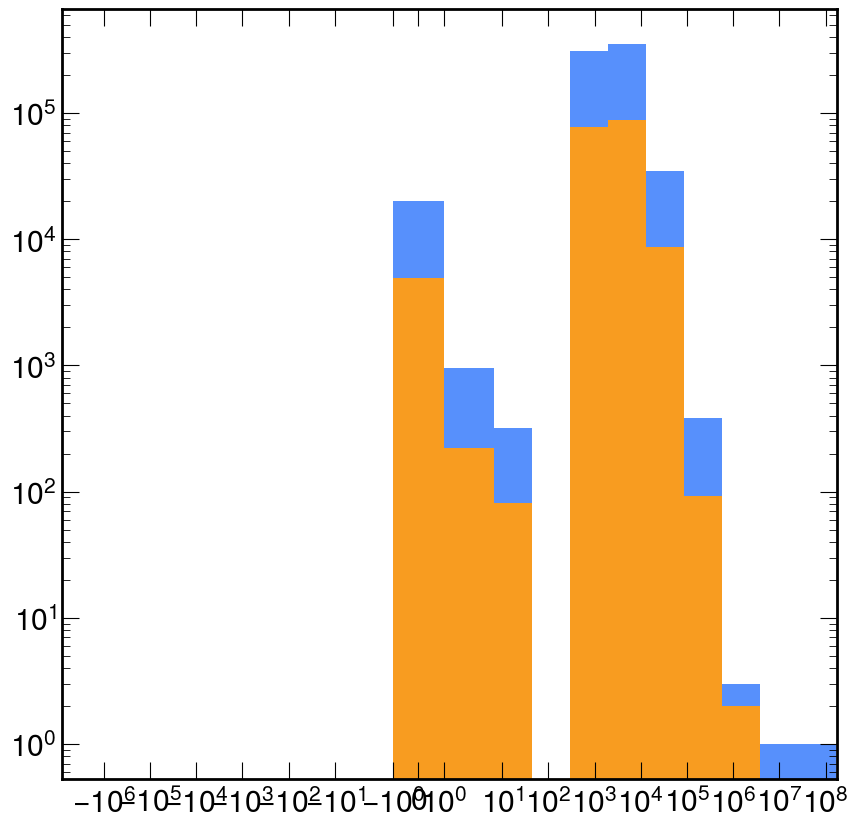

In [6]:
#inspecting weights
import matplotlib.pyplot as plt
print(X['weight'][:-20])

def symlog_bins(data, num_bins=10, linthresh=1.0):
    """
    Generates symlog spaced bins for histograms, handling both positive and negative values.

    Args:
        data (array-like): The data for which to generate bins.
        num_bins (int, optional): The desired number of bins. Defaults to 10.
        linthresh (float, optional): The threshold for the linear part of the symlog scale. 
                                     Values between -linthresh and linthresh will be linearly spaced. 
                                     Defaults to 1.0.

    Returns:
        numpy.ndarray: An array of bin edges.
    """
    min_val = np.min(data)
    max_val = np.max(data)
    print(min_val)

    # Handle the case where data is all zeros
    if min_val == 0 and max_val == 0:
        return np.linspace(0, 1, num_bins + 1)

    # Generate positive and negative bin edges separately
    pos_bins = np.logspace(np.log10(linthresh), np.log10(max_val), num=num_bins // 2 + 1) if max_val > linthresh else np.array([])
    neg_bins = -np.logspace(np.log10(linthresh), np.log10(-min_val), num=num_bins // 2 + 1) if min_val < -linthresh else np.array([])

    # Include the linear part of the symlog scale
    linear_bins = np.linspace(-linthresh, linthresh, num_bins % 2 + 1)

    # Combine the bins and sort them
    bins = np.concatenate((neg_bins, linear_bins, pos_bins))
    bins = np.unique(bins)  # Remove duplicates in case of overlapping ranges
    bins = np.sort(bins)
    return bins

bins =symlog_bins(X_train['weight_noxsec'],num_bins=20)


plt.hist(X_train['weight_noxsec'], bins=bins)
plt.hist(X_test['weight_noxsec'], bins=bins)

plt.yscale('log')
plt.xscale('symlog')
# plt.xlim([]
# print(X.columns)

DM_train = df2Dmatrix(X_train)
DM_test = df2Dmatrix(X_test)



In [38]:
# Define the BDT model
# import xgboost as xgb

# see https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
# for detailed explanations of parameters
model = xgb.XGBClassifier(
    n_estimators=100,  # number of boosting rounds (i.e. number of decision trees)
    max_depth=5,  # max depth of each decision tree
    learning_rate=0.1,
    early_stopping_rounds=20,  # how many rounds to wait to see if the loss is going down
)

In [39]:
omit_cols = ['isSignal', 'weight', 'weight_noxsec','category']
trained_model = model.fit(
    X_train.drop(omit_cols, axis=1), #data should not include label column OR weights
    X_train['isSignal'], #labels
    # Y_train_val,
    # xgboost uses the last set for early stopping
    # https://xgboost.readthedocs.io/en/stable/python/python_intro.html#early-stopping
    eval_set=[(X_train.drop(omit_cols, axis=1), X_train['isSignal']), 
              (X_test.drop(omit_cols, axis=1), X_test['isSignal'])],  # sets for which to save the loss
    verbose=True,
)

[0]	validation_0-logloss:0.18106	validation_1-logloss:0.17992
[1]	validation_0-logloss:0.16753	validation_1-logloss:0.16643
[2]	validation_0-logloss:0.15601	validation_1-logloss:0.15489
[3]	validation_0-logloss:0.14608	validation_1-logloss:0.14496
[4]	validation_0-logloss:0.13747	validation_1-logloss:0.13634
[5]	validation_0-logloss:0.12977	validation_1-logloss:0.12863
[6]	validation_0-logloss:0.12296	validation_1-logloss:0.12183
[7]	validation_0-logloss:0.11701	validation_1-logloss:0.11588
[8]	validation_0-logloss:0.11174	validation_1-logloss:0.11062
[9]	validation_0-logloss:0.10699	validation_1-logloss:0.10588
[10]	validation_0-logloss:0.10270	validation_1-logloss:0.10158
[11]	validation_0-logloss:0.09898	validation_1-logloss:0.09789
[12]	validation_0-logloss:0.09562	validation_1-logloss:0.09455
[13]	validation_0-logloss:0.09256	validation_1-logloss:0.09153
[14]	validation_0-logloss:0.08975	validation_1-logloss:0.08873
[15]	validation_0-logloss:0.08735	validation_1-logloss:0.08636
[1

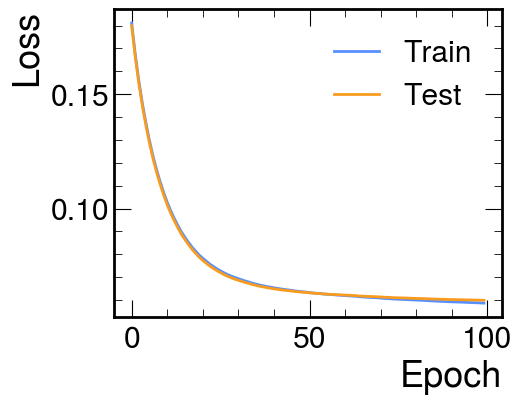

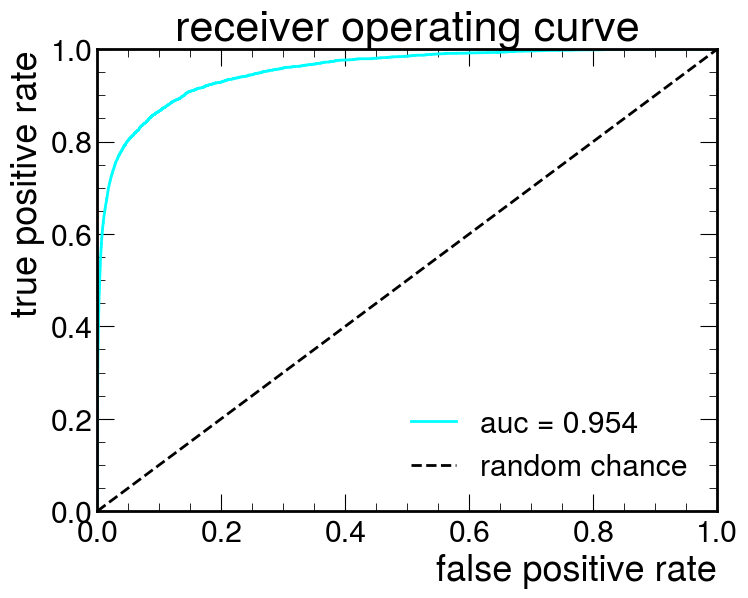

In [40]:
evals_result = trained_model.evals_result()

fig = plt.figure(figsize=(5, 4))
for i, label in enumerate(["Train", "Test"]):
    plt.plot(evals_result[f"validation_{i}"]["logloss"], label=label, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Plot ROC
Y_predict = model.predict_proba(X_test.drop(omit_cols, axis=1))
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(X_test['isSignal'], Y_predict[:, 1])
roc_auc = auc(fpr, tpr)


fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(fpr, tpr, lw=2, color="cyan", label="auc = %.3f" % (roc_auc))
ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="k", label="random chance")
ax.set_xlim([0, 1.0])
ax.set_ylim([0, 1.0])
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("receiver operating curve")
ax.legend(loc="lower right")
plt.show()

(179456,)
(179456, 1)


Text(0.5, 1.0, 'S/B classifer scores by channel')

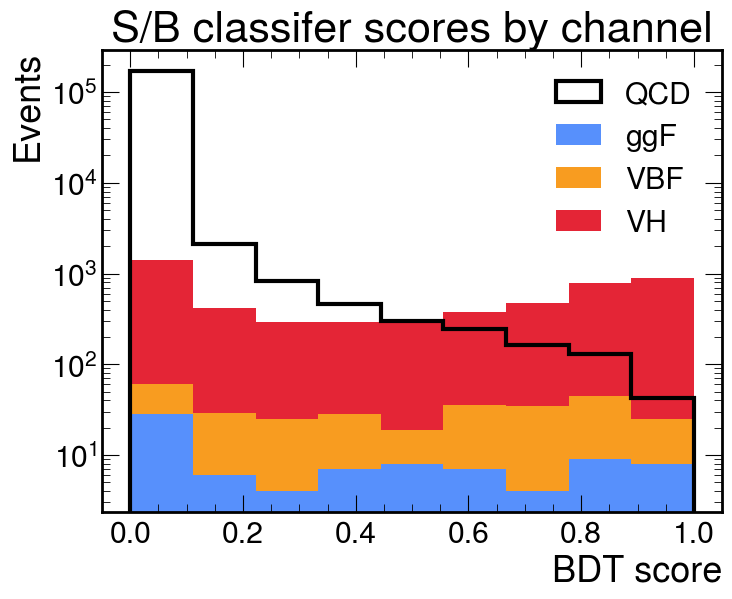

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (8,6))
samples = ['QCD', 'ggF', 'VBF', 'VH', ]
colors = ['black', [0.6,1,0.6], [0,0.8,0], [0,0.3,0]]
print(Y_predict[:, 1].shape)
print(X_test['weight'].shape)

bins = np.linspace(0,1,10)
signals = pd.DataFrame()
for i, s in enumerate(samples[1:]):
    category_mask = X_test['category'] == s
    w = X_test['weight'][category_mask][0]
    data = pd.DataFrame(Y_predict[category_mask, 1], columns=[s])
    signals = pd.concat([signals, data], axis=1)
    # if s is not 'QCD':
    #     # ax.hist(Y_predict[category_mask, 1], color = colors[i], label = samples[i], stacked=True, linewidth=3, bins=bins #weights = w
    #        )
    # else:
    #     ax.hist(Y_predict[category_mask, 1], histtype='step', color = colors[i], label = samples[i], stacked=False, linewidth=3, bins=bins #weights = w
    #        )




QCD_mask =  X_test['category'] == 'QCD'
ax.hist(Y_predict[QCD_mask, 1], histtype='step', color = colors[0], label = samples[0], stacked=False, linewidth=3, bins=bins #weights = w
           )
ax.hist(signals, #color = colors[1:],
        label =signals.columns, stacked=True, linewidth=3, bins=bins #weights = w
           )
    
ax.set_yscale('log')
ax.legend(samples)
ax.set_ylabel('Events')
ax.set_xlabel('BDT score')
ax.set_title('S/B classifer scores by channel')

In [12]:
# import shap

ModuleNotFoundError: No module named 'shap'

[0.00479275 0.08237978 0.00187087 0.0355341  0.03742228 0.02410875
 0.0100051  0.0118716  0.01010039 0.01126496 0.02144022 0.01697517
 0.06249609 0.01729442 0.07258159 0.04960755 0.01035455 0.00913047
 0.01411726 0.0092746  0.01431009 0.0168518  0.0364041  0.07341865
 0.21407792 0.13231489]
                    Feature  importance
0            ak8FatJetEta 0    0.004793
1            ak8FatJetEta 1    0.082380
2            ak8FatJetPhi 0    0.001871
3            ak8FatJetPhi 1    0.035534
4             ak8FatJetPt 0    0.037422
5             ak8FatJetPt 1    0.024109
6       ak8FatJetPNetTXjj 0    0.010005
7       ak8FatJetPNetTXjj 1    0.011872
8       ak8FatJetPNetTXgg 0    0.010100
9       ak8FatJetPNetTXgg 1    0.011265
10      ak8FatJetPNetTXcc 0    0.021440
11      ak8FatJetPNetTXcc 1    0.016975
12      ak8FatJetPNetTXqq 0    0.062496
13      ak8FatJetPNetTXqq 1    0.017294
14  ak8FatJetTau2OverTau1 0    0.072582
15  ak8FatJetTau2OverTau1 1    0.049608
16  ak8FatJetTau3OverTau2 0 

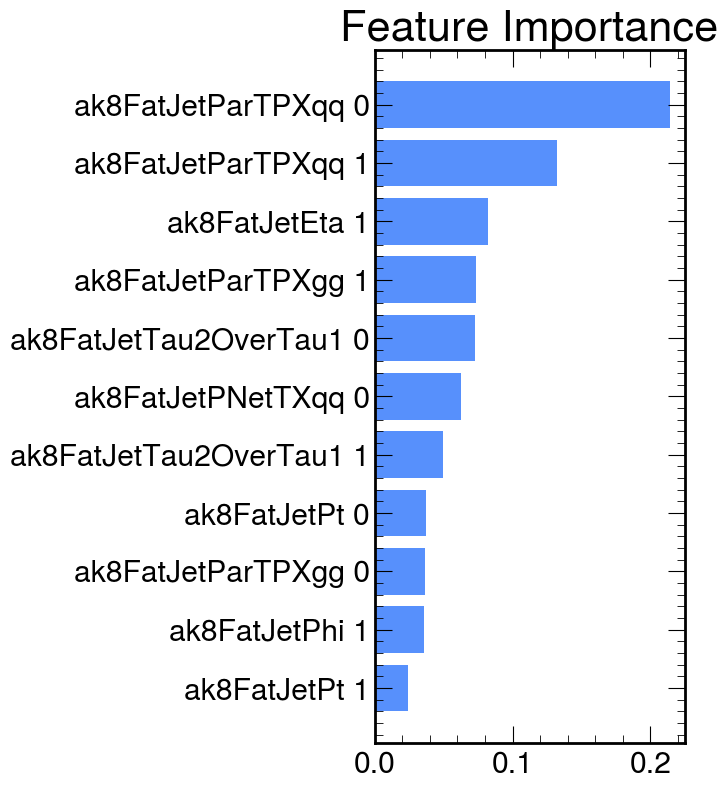

In [52]:
print(trained_model.feature_importances_)
plt.figure(figsize=(4,9))
# plot
# c = X_train.columns
# fields = np.unique(np.array([c[0] for c in X_train.columns]))

# fields=np.array([c[0] for c in X_train.columns])
fields= trained_model.get_booster().feature_names
imp = trained_model.feature_importances_

# mask = [f for f in fields if 'QCD' not in f]

feat_imp = pd.DataFrame({'Feature':fields, 'importance':imp})
# feat_imp = feat_imp.loc[mask]
print(feat_imp)
feat_imp = feat_imp.sort_values(by = 'importance', ascending=True).reset_index()

feat_imp = feat_imp.loc[15:25]
print(feat_imp['Feature'])
y = range(len(feat_imp))

plt.barh(y, feat_imp['importance'])
# plt.invert_yaxis()
# plt.bar(fields, trained_model.feature_importances_)
plt.yticks(y, labels=feat_imp['Feature'])
plt.title('Feature Importance')

# plt.show()

plt.savefig('featureImp_full.png',  bbox_inches='tight')